In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
X_train_lr = pd.read_csv('../data/processed/X_train_lr.csv', index_col=0)
X_test_lr = pd.read_csv('../data/processed/X_test_lr.csv', index_col=0)
y_train = pd.read_csv('../data/processed/y_train.csv', index_col=0)
y_test = pd.read_csv('../data/processed/y_test.csv', index_col=0)

X_train = pd.read_csv('../data/processed/X_train.csv', index_col=0)
X_test = pd.read_csv('../data/processed/X_test.csv', index_col=0)


df = pd.read_csv('../data/df-no-passes.csv')

Самая простая модель - отправная точка для сравнения. Используем данные без мультиколлинеарных признаков (X_train_lr). Метрики считаем через cross_validate на трейне, финальные - на тесте.

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error


lr_model = LinearRegression()

score = cross_validate(lr_model, X_train_lr, y_train, cv=10, scoring={
  'rmse': 'neg_root_mean_squared_error',
  'mae': 'neg_mean_absolute_error',
  'r2': 'r2'
  })

rmse_cv = -score['test_rmse'].mean()
mae_cv = -score['test_mae'].mean()
r2_cv = score['test_r2'].mean()

lr_model.fit(X_train_lr, y_train)
lr_predicted = lr_model.predict(X_test_lr)

print('====================')
print(f'Для линейной модели на тренировочной выборке:')
print('В логарифмической шкале')
print(f'rmse_cv - {rmse_cv}')
print(f'mae_cv - {mae_cv}')
print(f'r2_cv - {r2_cv}')

print('============')
print(f'Средняя цена дома - {np.expm1(df['SalePrice'].mean()):.2f}')
print(f'rmse - {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(lr_predicted))):.2f}')
print(f'mae - {mean_absolute_error(np.expm1(y_test), np.expm1(lr_predicted)):.2f}')


Для линейной модели на тренировочной выборке:
В логарифмической шкале
rmse_cv - 0.18185761462771569
mae_cv - 0.09559404147528036
r2_cv - 0.7345608562342536
Средняя цена дома - 166716.73
rmse - 25542.57
mae - 15682.33


RMSE CV=0.182, MAE CV=0.096, R²=0.73. Модель объясняет 73% вариации цен. Средняя ошибка примерно $15k - для baseline приемлемо.

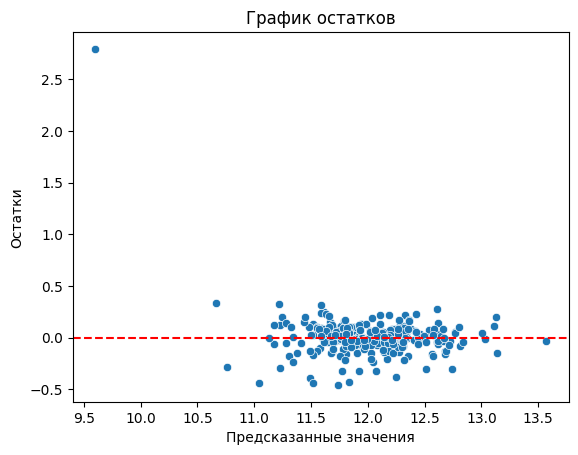

In [4]:
residuals = y_test.values - lr_predicted

sns.scatterplot(x=lr_predicted.flatten(), y=residuals.flatten())
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.show()

График остатков показывает что большинство ошибок случайны и близки к нулю — линейная зависимость частично уловлена. Один сильный выброс слева — модель сильно ошиблась на одном объекте.

In [41]:
from sklearn.model_selection import GridSearchCV

def find_best_params(modelClass, default_param, grid_param, X, y, scoring):
  model = modelClass(**default_param)

  grid = GridSearchCV(model, grid_param, cv=10, scoring=scoring, error_score='raise')
  grid.fit(X, y)

  print(f'Лучшие параметры - {grid.best_params_}')
  print(f'Лучший {scoring} - {-grid.best_score_}')

  return grid

Регуляризованные модели: Ridge, Lasso, ElasticNet

In [6]:
from sklearn.linear_model import Ridge

best_model_ridge = find_best_params(Ridge, 
                 {
                   'fit_intercept': True
                 },
                 {
                   'alpha': [0.01, 0.1, 1, 10, 100, 1000]
                 },
                 X_train_lr,
                 y_train,
                 'neg_root_mean_squared_error')

ridge_predicted = best_model_ridge.best_estimator_.predict(X_test_lr)

print('==========')
print(f'Средняя цена дома - {np.expm1(df['SalePrice'].mean()):.2f}')
print(f'rmse - {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(ridge_predicted))):.2f}')

Лучшие параметры - {'alpha': 100}
Лучший neg_root_mean_squared_error - 0.1468311669405724
Средняя цена дома - 166716.73
rmse - 25384.86


In [7]:
from sklearn.linear_model import Lasso

best_model_lasso = find_best_params(Lasso, 
                                    {
                                      'fit_intercept': True
                                    },
                                    {
                                      'alpha': [0.01, 0.1, 1, 10, 100, 1000]
                                    },
                                    X_train_lr,
                                    y_train,
                                    'neg_root_mean_squared_error')

lasso_predicted = best_model_lasso.best_estimator_.predict(X_test_lr)

print('==========')
print(f'Средняя цена дома - {np.expm1(df['SalePrice'].mean()):.2f}')
print(f'rmse - {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(lasso_predicted))):.2f}')

Лучшие параметры - {'alpha': 0.01}
Лучший neg_root_mean_squared_error - 0.14826343987205753
Средняя цена дома - 166716.73
rmse - 28710.62


In [9]:
from sklearn.linear_model import ElasticNet

best_model_elastic = find_best_params(ElasticNet,
                                      {
                                        'max_iter': 100000
                                      },
                                      {
                                        'l1_ratio': [0.01, 0.1, 0.3, 0.5, 0.7, 0.9, 0.99, 1],
                                        'alpha': [0.0001, 0.01, 0.1, 1, 10, 100, 1000]
                                      },
                                      X_train_lr,
                                      y_train,
                                      'neg_root_mean_squared_error'
                                      )

elastic_predicted = best_model_elastic.best_estimator_.predict(X_test_lr)

print('==========')
print(f'Средняя цена дома - {np.expm1(df['SalePrice'].mean()):.2f}')
print(f'rmse - {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(elastic_predicted))):.2f}')


Лучшие параметры - {'alpha': 0.1, 'l1_ratio': 0.01}
Лучший neg_root_mean_squared_error - 0.14455555969174347
Средняя цена дома - 166716.73
rmse - 25865.40


ElasticNet с l1_ratio=0.01 (почти чистый Ridge) показал лучший результат

In [10]:
top_cols = ['OverallQual', 'GrLivArea', 'TotalSF', 'HouseAge', 'GarageCars']

X_train_poly = X_train_lr[top_cols]
X_test_poly = X_test_lr[top_cols]

Проверяем нелинейные зависимости. Из-за большого числа признаков после OHE берём топ-5 по корреляции с таргетом. Метод локтя покажет оптимальную степень.

In [27]:
from sklearn.preprocessing import PolynomialFeatures

degrees = [1, 2, 3, 4, 5]
rmse_train = []
rmse_test = []

for degree in degrees:
  poly = PolynomialFeatures(degree=degree, include_bias=False, interaction_only=False)
  X_train_p = poly.fit_transform(X_train_poly)
  X_test_p = poly.transform(X_test_poly)

  model_poly = LinearRegression(fit_intercept=True)
  model_poly.fit(X_train_p, y_train)

  train_predicted = model_poly.predict(X_train_p)
  rmse_train.append(np.sqrt(mean_squared_error(y_train, train_predicted)))

  test_predicted = model_poly.predict(X_test_p)
  rmse_test.append(np.sqrt(mean_squared_error(y_test, test_predicted)))


print(f'Степень полинома с лучшим показателем на тренировочной выборке - {rmse_train.index(min(rmse_train)) + 1}')
print(f'Лучший rmse - {min(rmse_train):.2f}')
print('======================')
print(f'Лучшая степень полинома на тестовой выборке - {rmse_test.index(min(rmse_test)) + 1}')
print(f'Лучший rmse - {min(rmse_test):.2f}')

Степень полинома с лучшим показателем на тренировочной выборке - 5
Лучший rmse - 0.12
Лучшая степень полинома на тестовой выборке - 2
Лучший rmse - 0.17


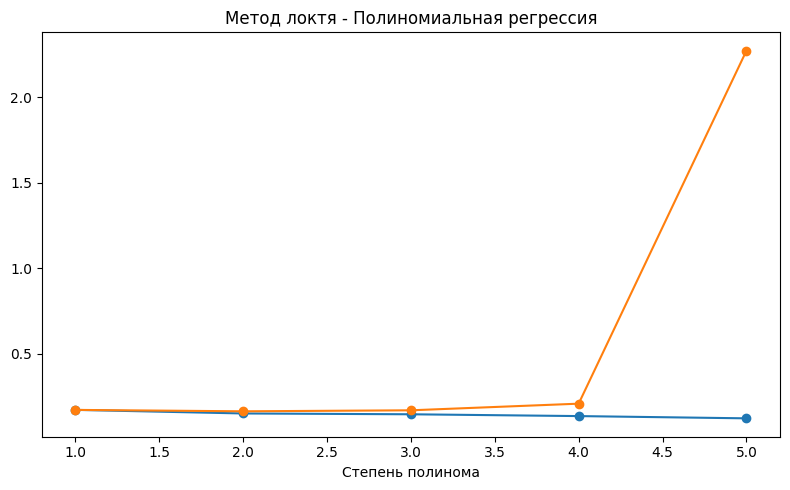

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(degrees, rmse_train, label='Train rmse', marker='o')
plt.plot(degrees, rmse_test, label='Test rmse', marker='o')
plt.xlabel('Степень полинома')
plt.title('Метод локтя - Полиномиальная регрессия')
plt.tight_layout()
plt.show()

KNN предсказывает цену как среднее K ближайших соседей в пространстве признаков. Используем полный датасет

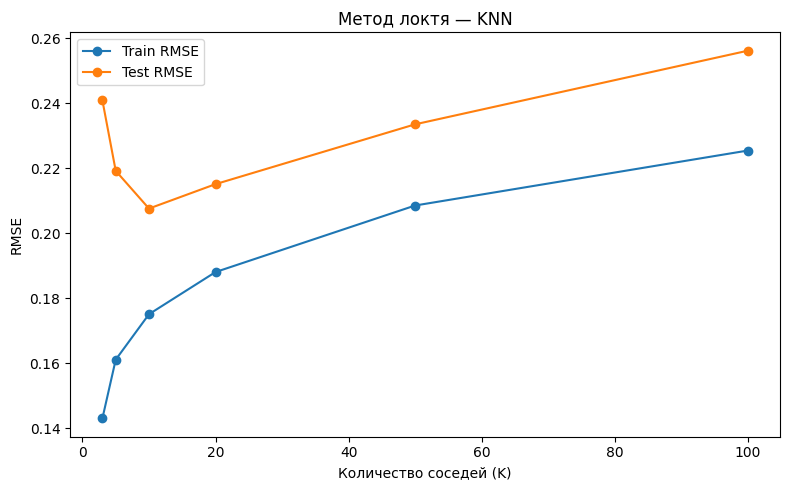

In [31]:
from sklearn.neighbors import KNeighborsRegressor

neighbors = [3, 5, 10, 20, 50, 100]
rmse_train = []
rmse_test = []

for k in neighbors:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    rmse_train.append(np.sqrt(mean_squared_error(y_train, knn.predict(X_train))))
    rmse_test.append(np.sqrt(mean_squared_error(y_test, knn.predict(X_test))))

plt.figure(figsize=(8, 5))
plt.plot(neighbors, rmse_train, label='Train RMSE', marker='o')
plt.plot(neighbors, rmse_test, label='Test RMSE', marker='o')
plt.xlabel('Количество соседей (K)')
plt.ylabel('RMSE')
plt.title('Метод локтя — KNN')
plt.legend()
plt.tight_layout()
plt.show()

KNN показывает классическую картину bias-variance tradeoff. Оптимальное K=10 даёт Test RMSE=0.205 - хуже линейных моделей с регуляризацией. Причина: проклятие размерности - при 200+ признаках после OHE расстояния между точками теряют смысл, все объекты становятся примерно одинаково далёкими.

In [43]:
from sklearn.svm import SVR

best_model_svr = find_best_params(SVR, {}, 
                              {
                                'kernel': ['rbf'],
                                'C': [0.1, 0.5, 1],
                                'gamma': ['scale', 'auto'],
                                'epsilon': [0.1, 0.5, 1, 2]
                              },
                              X_train,
                              y_train.values.flatten(),
                              'neg_root_mean_squared_error')

svr_predicted = best_model_svr.best_estimator_.predict(X_test)

print('==========')
print(f'Средняя цена дома - {np.expm1(df['SalePrice'].mean()):.2f}')
print(f'rmse - {np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(svr_predicted))):.2f}')

Лучшие параметры - {'C': 1, 'epsilon': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Лучший neg_root_mean_squared_error - 0.18551395378792346
Средняя цена дома - 166716.73
rmse - 45203.51
